In [ ]:
!pip install ultralytics -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


unzip:  cannot find or open /content/idd-dataset-cv-20260419T075744Z-3-001.zip, /content/idd-dataset-cv-20260419T075744Z-3-001.zip.zip or /content/idd-dataset-cv-20260419T075744Z-3-001.zip.ZIP.
✅ Dataset unzipped to: /content/drive/MyDrive/idd_project_results/idd_dataset/


In [ ]:
import os

drive_dataset_path = '/content/drive/MyDrive/idd_project_results/idd_dataset/'
drive_output_path = '/content/drive/MyDrive/idd_project_results/yolo_output/'

os.makedirs(drive_dataset_path, exist_ok=True)
os.makedirs(drive_output_path, exist_ok=True)



In [ ]:
zip_file_path = '/content/idd_dense_dataset.zip'

# Unzip the provided dataset to Google Drive
!unzip -q "{zip_file_path}" -d "{drive_dataset_path}"
print(f"✅ Dataset unzipped to: {drive_dataset_path}")

[/content/idd_dense_dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/idd_dense_dataset.zip or
        /content/idd_dense_dataset.zip.zip, and cannot find /content/idd_dense_dataset.zip.ZIP, period.
✅ Dataset unzipped to: /content/drive/MyDrive/idd_project_results/idd_dataset/


In [ ]:
!cp "/content/drive/MyDrive/idd_dense_dataset.zip" /content/idd_dense_dataset.zip
print("Copy complete!") # Commented out as dataset is directly unzipped to drive and this file causes an error

cp: cannot stat '/content/drive/MyDrive/idd_dense_dataset.zip': No such file or directory
Copy complete!


In [ ]:
!unzip -q /content/drive/MyDrive/idd_dense_dataset.zip
print("Unzip complete!") # Commented out as dataset is directly unzipped to drive

[/content/drive/MyDrive/idd_dense_dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/drive/MyDrive/idd_dense_dataset.zip or
        /content/drive/MyDrive/idd_dense_dataset.zip.zip, and cannot find /content/drive/MyDrive/idd_dense_dataset.zip.ZIP, period.
Unzip complete!


In [ ]:
import os

local_zip_path = '/content/idd_dense_dataset.zip'
drive_zip_path = '/content/drive/MyDrive/idd_dense_dataset.zip'
local_dataset_extract_path = '/content/local_dataset/'

# 1. Remove potentially problematic local zip file
if os.path.exists(local_zip_path):
    os.remove(local_zip_path)
    print(f"Removed old local zip file: {local_zip_path}")

# 2. Re-copy the zip file from Drive to local content
!cp "{drive_zip_path}" "{local_zip_path}"
print("✅ Re-copy complete!")

# 3. Clean up existing local_dataset directory before unzipping
if os.path.exists(local_dataset_extract_path):
    import shutil
    shutil.rmtree(local_dataset_extract_path)
    print(f"Removed old local dataset directory: {local_dataset_extract_path}")

# 4. Attempt to unzip again
!unzip -q "{local_zip_path}" -d "{local_dataset_extract_path}"
print("✅ Unzip complete!")


Removed old local zip file: /content/idd_dense_dataset.zip
✅ Re-copy complete!
[/content/idd_dense_dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/idd_dense_dataset.zip or
        /content/idd_dense_dataset.zip.zip, and cannot find /content/idd_dense_dataset.zip.ZIP, period.
✅ Unzip complete!


In [ ]:

drive_dataset_path = '/content/drive/MyDrive/idd_project_results/idd_dataset/'
drive_output_path = '/content/drive/MyDrive/idd_project_results/yolo_output/'

In [ ]:
import os
import yaml
import shutil
import random

# Use the drive_dataset_path defined earlier
base_path = drive_dataset_path
# Sometimes unzipping creates a nested folder, let's find the real root
for root, dirs, files in os.walk(base_path):
    if 'images' in dirs and 'labels' in dirs:
        base_path = root
        break

print(f"✅ Found local dataset root at: {base_path}")

# Check val folder
val_images_path = os.path.join(base_path, 'images', 'val')
train_images_path = os.path.join(base_path, 'images', 'train')

# Ensure train and val label paths are defined
val_labels_path = os.path.join(base_path, 'labels', 'val')
train_labels_path = os.path.join(base_path, 'labels', 'train')

# Ensure all necessary directories exist
os.makedirs(val_images_path, exist_ok=True)
os.makedirs(val_labels_path, exist_ok=True)
os.makedirs(train_images_path, exist_ok=True)
os.makedirs(train_labels_path, exist_ok=True)


if not os.path.exists(val_images_path) or len(os.listdir(val_images_path)) == 0:
    print("⚠️ Running the 80/20 split on local storage...")


    all_images = [f for f in os.listdir(train_images_path) if f.endswith('.jpg')]
    if len(all_images) == 0:
        print("❌ CRITICAL ERROR: No images found in the zip file!")
    else:
        val_samples = random.sample(all_images, min(800, len(all_images)))
        for img_name in val_samples:
            label_name = img_name.replace('.jpg', '.txt')
            shutil.move(os.path.join(train_images_path, img_name), os.path.join(val_images_path, img_name))
            if os.path.exists(os.path.join(train_labels_path, label_name)):
                shutil.move(os.path.join(train_labels_path, label_name), os.path.join(val_labels_path, label_name))
        print("✅ Validation split complete!")
else:
    print("✅ The 'val' folder exists!")

# Auto-fix dataset.yaml and save to Drive output path
data = {
    'path': base_path,
    'train': 'images/train',
    'val': 'images/val',
    'nc': 15,
    'names': ['car', 'bus', 'autorickshaw', 'motorcycle', 'pedestrian', 'rider', 'truck', 'traffic sign', 'traffic light', 'bicycle', 'animal', 'caravan', 'trailer', 'train', 'other']
}
with open(os.path.join(drive_output_path, 'dataset.yaml'), 'w') as f:
    yaml.dump(data, f, default_flow_style=False)
print("✅ dataset.yaml has been auto-corrected for local training.")

✅ Found local dataset root at: /content/drive/MyDrive/idd_project_results/idd_dataset/
⚠️ Running the 80/20 split on local storage...
❌ CRITICAL ERROR: No images found in the zip file!
✅ dataset.yaml has been auto-corrected for local training.


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data=os.path.join('/content/drive/MyDrive/idd_project_results/yolo_output/dataset.yaml'),
    epochs=50,
    imgsz=640,
    batch=16,
    project=drive_output_path, # Save results to Drive
    name='baseline_dense_local',
    save=True,
    plots=True
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/idd_project_results/yolo_output/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_dense_local-8, nbs=64, nms=False, opset=None, optimize=

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/drive/MyDrive/idd_project_results/idd_dataset/images/train
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [ ]:
import os
import random
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Load YOUR newly trained baseline model
# (YOLO automatically saves the best weights in this folder)
model_path = os.path.join(drive_output_path, 'baseline_dense_local', 'weights', 'best.pt')
model = YOLO(model_path)

# 2. Pick 20 random images from your validation set
val_images_dir = os.path.join(drive_dataset_path, 'dataset', 'images', 'val')
all_val_images = [os.path.join(val_images_dir, f) for f in os.listdir(val_images_dir) if f.endswith('.jpg')]
sample_images = random.sample(all_val_images, min(20, len(all_val_images)))

# 3. Run predictions and save the images with drawn bounding boxes
print("Running predictions to find NMS failures...")
results = model.predict(
    source=sample_images,
    conf=0.25,        # Confidence threshold
    iou=0.45,         # Standard NMS threshold (This is what we are critiquing!)
    save=True,        # Saves images with boxes drawn
    project=drive_output_path, # Save predictions to Drive
    name='visual_proof'
)

print(f"\n✅ Predictions saved! Check the folder: {os.path.join(drive_output_path, 'visual_proof')}")

Running predictions to find NMS failures...

0: 640x640 7 cars, 4 buss, 1 pedestrian, 2 trucks, 1 traffic light, 11.2ms
1: 640x640 2 cars, 4 buss, 2 autorickshaws, 1 motorcycle, 6 pedestrians, 1 rider, 1 truck, 1 traffic sign, 11.2ms
2: 640x640 1 car, 1 motorcycle, 1 pedestrian, 1 truck, 1 traffic light, 11.2ms
3: 640x640 4 cars, 2 buss, 2 autorickshaws, 4 motorcycles, 10 pedestrians, 1 rider, 1 traffic sign, 11.2ms
4: 640x640 2 buss, 4 autorickshaws, 7 pedestrians, 3 riders, 2 trucks, 11.2ms
5: 640x640 7 cars, 2 autorickshaws, 4 motorcycles, 2 pedestrians, 1 rider, 2 traffic signs, 11.2ms
6: 640x640 3 cars, 3 buss, 2 autorickshaws, 1 motorcycle, 3 pedestrians, 4 trucks, 11.2ms
7: 640x640 1 car, 5 buss, 2 autorickshaws, 4 motorcycles, 2 pedestrians, 1 truck, 2 traffic signs, 2 traffic lights, 11.2ms
8: 640x640 2 cars, 5 buss, 1 autorickshaw, 1 motorcycle, 8 pedestrians, 4 trucks, 1 traffic light, 11 animals, 11.2ms
9: 640x640 5 cars, 7 buss, 3 autorickshaws, 7 pedestrians, 5 riders, 3 

✅ Displaying NMS Failure Proofs (Showing up to 4 images):

📸 image3.jpg


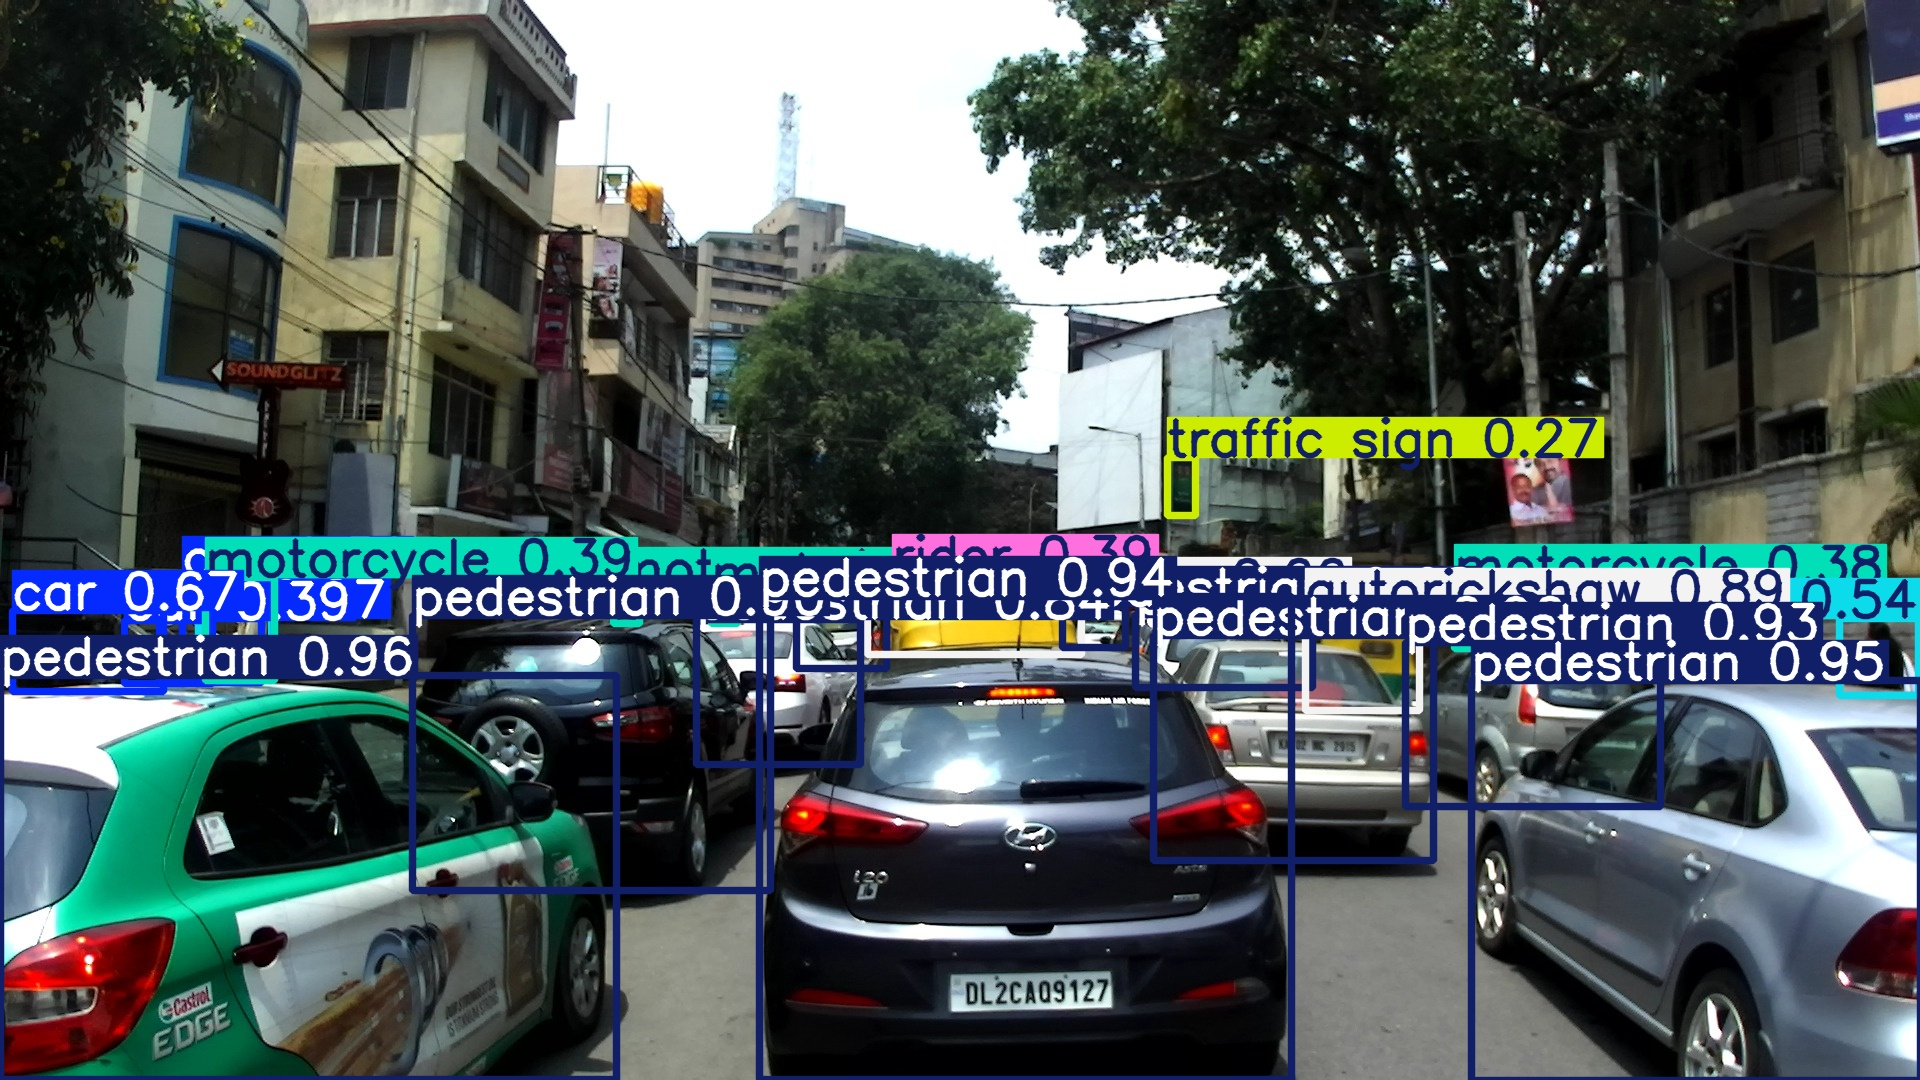



📸 image5.jpg


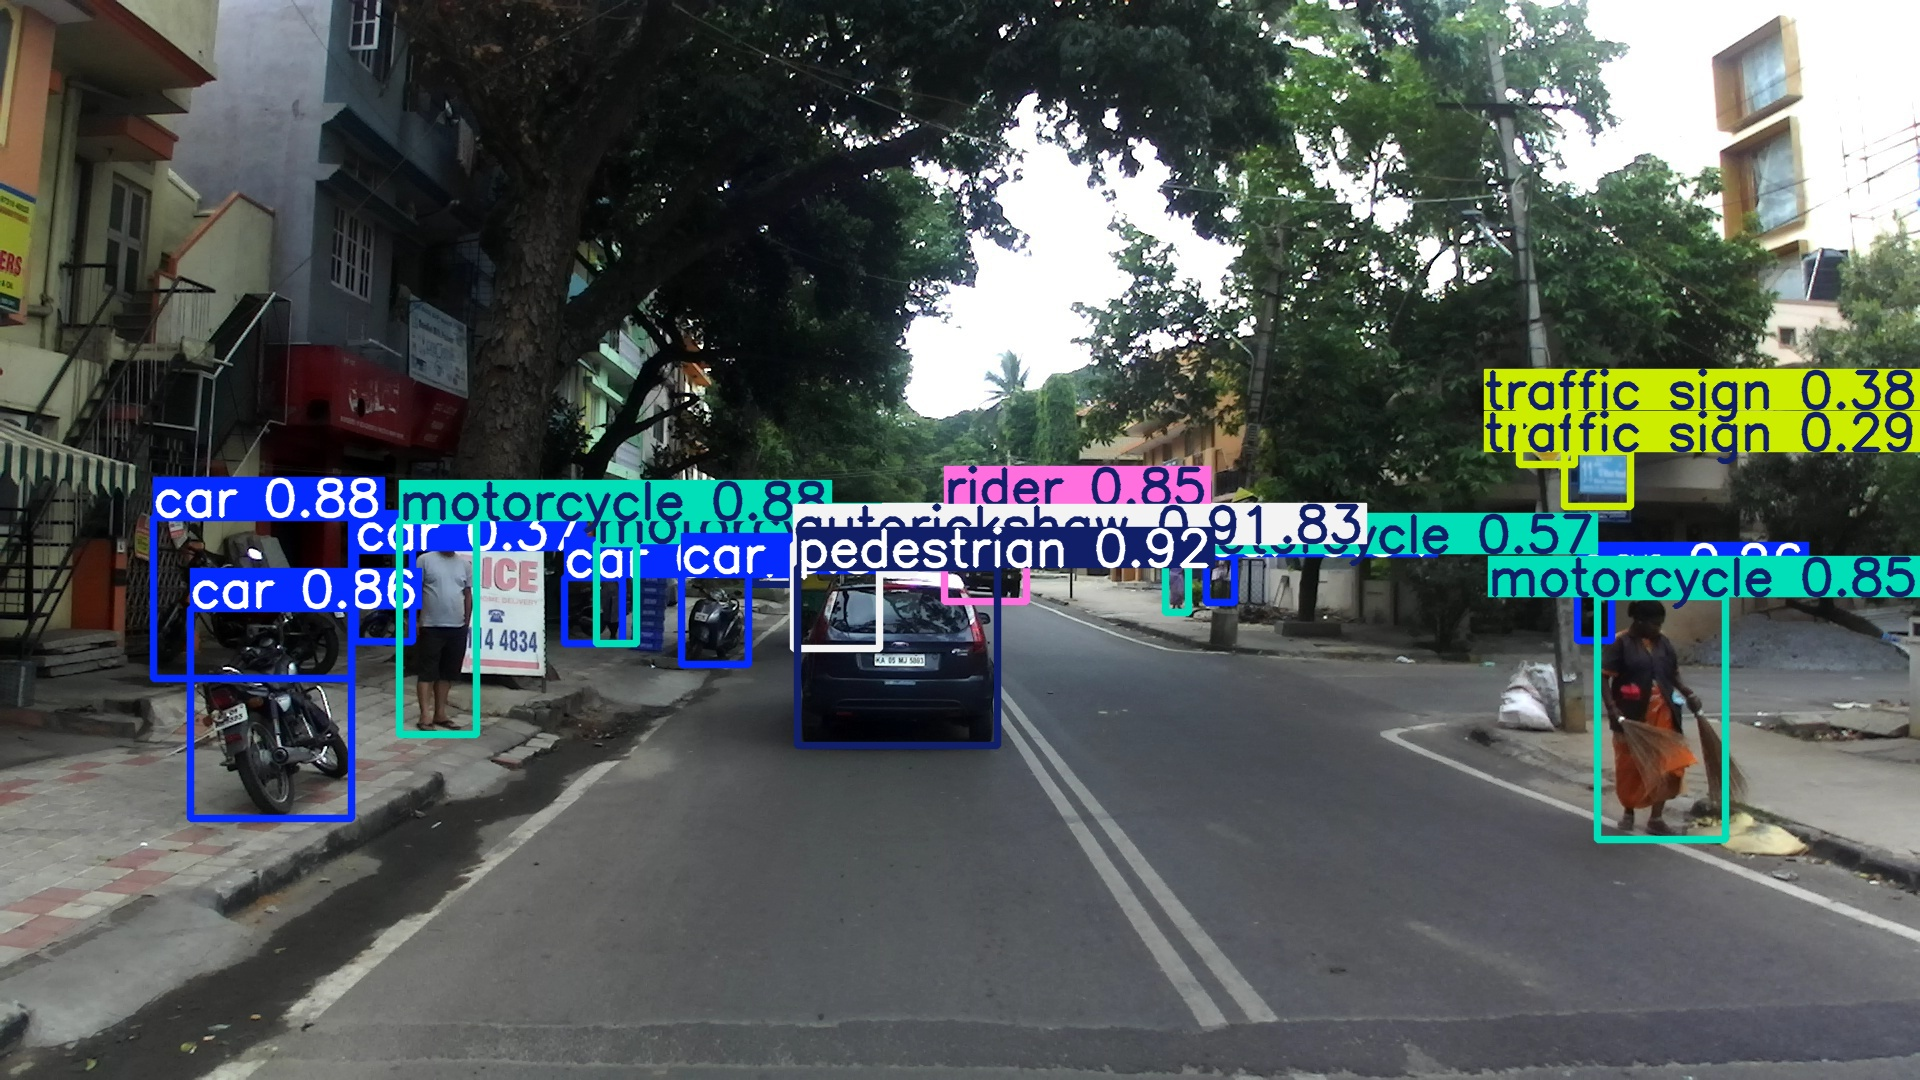



📸 image19.jpg


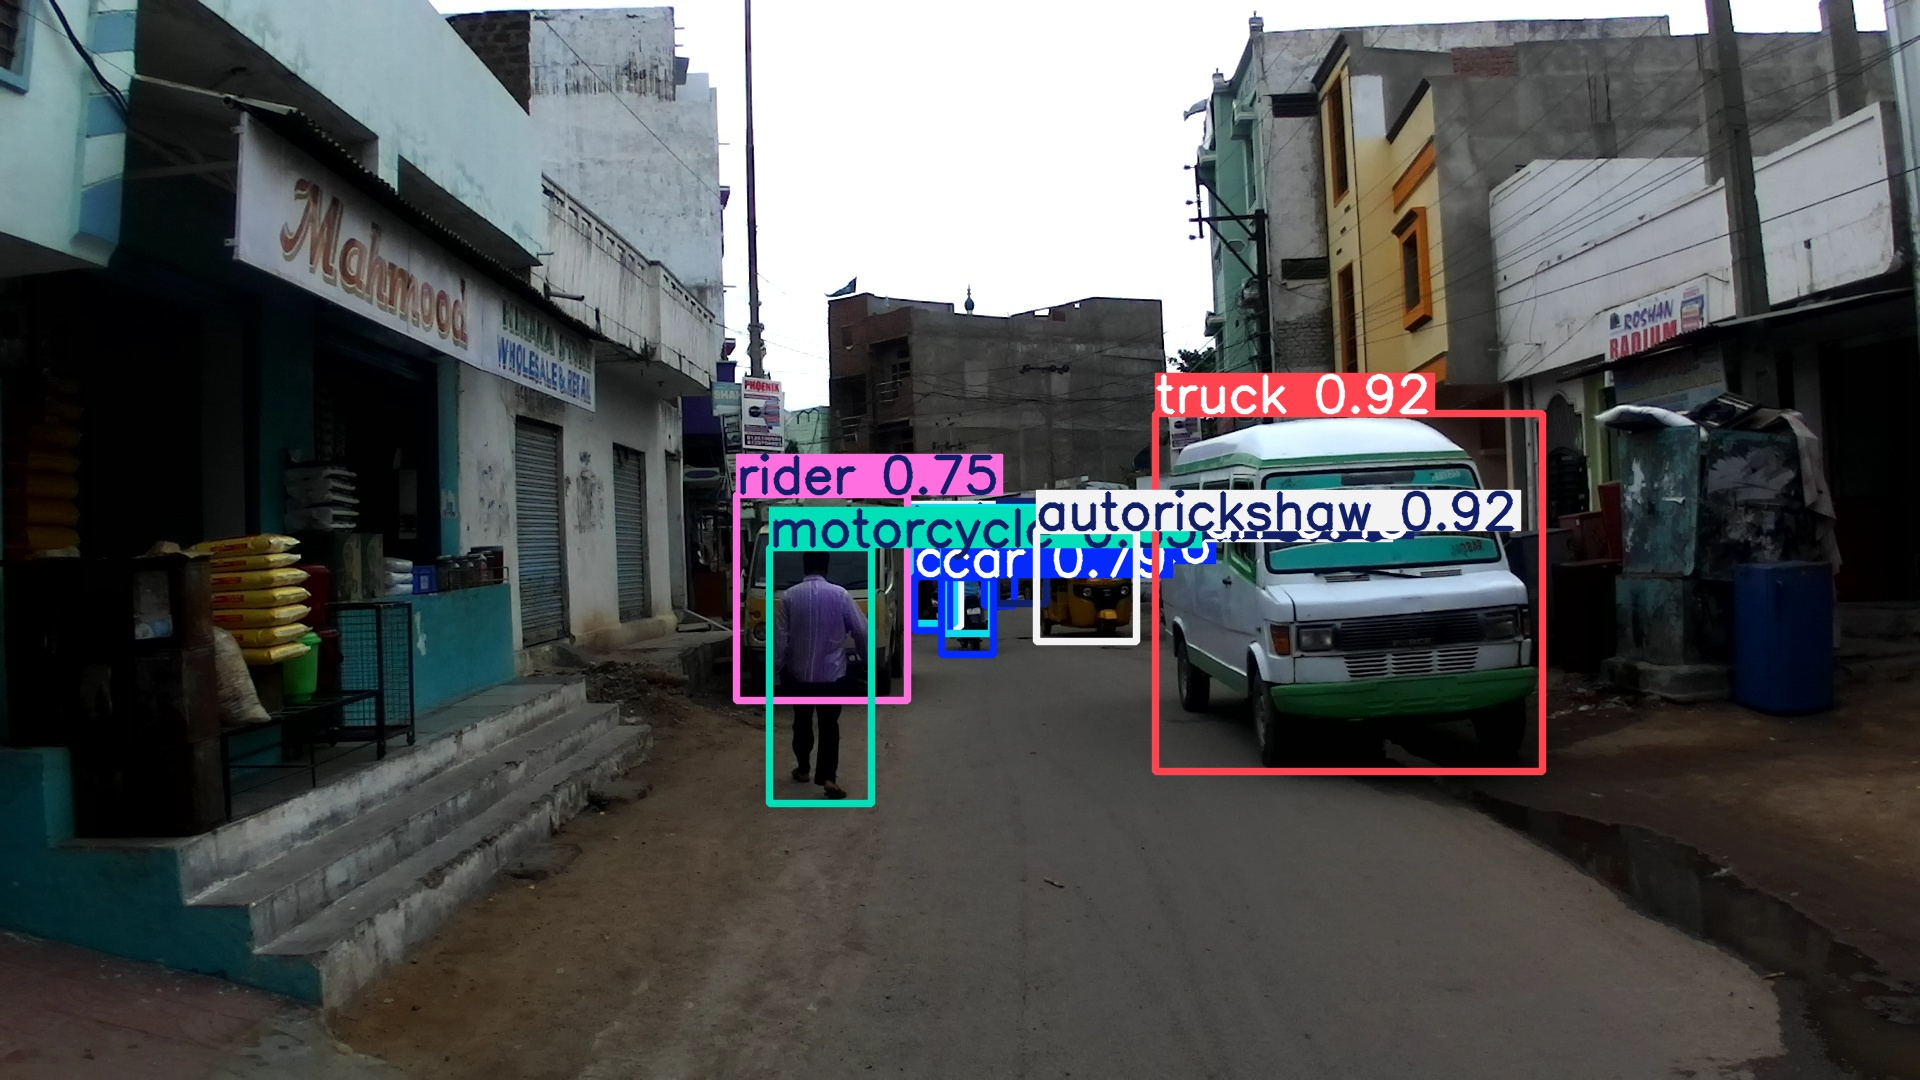



📸 image12.jpg


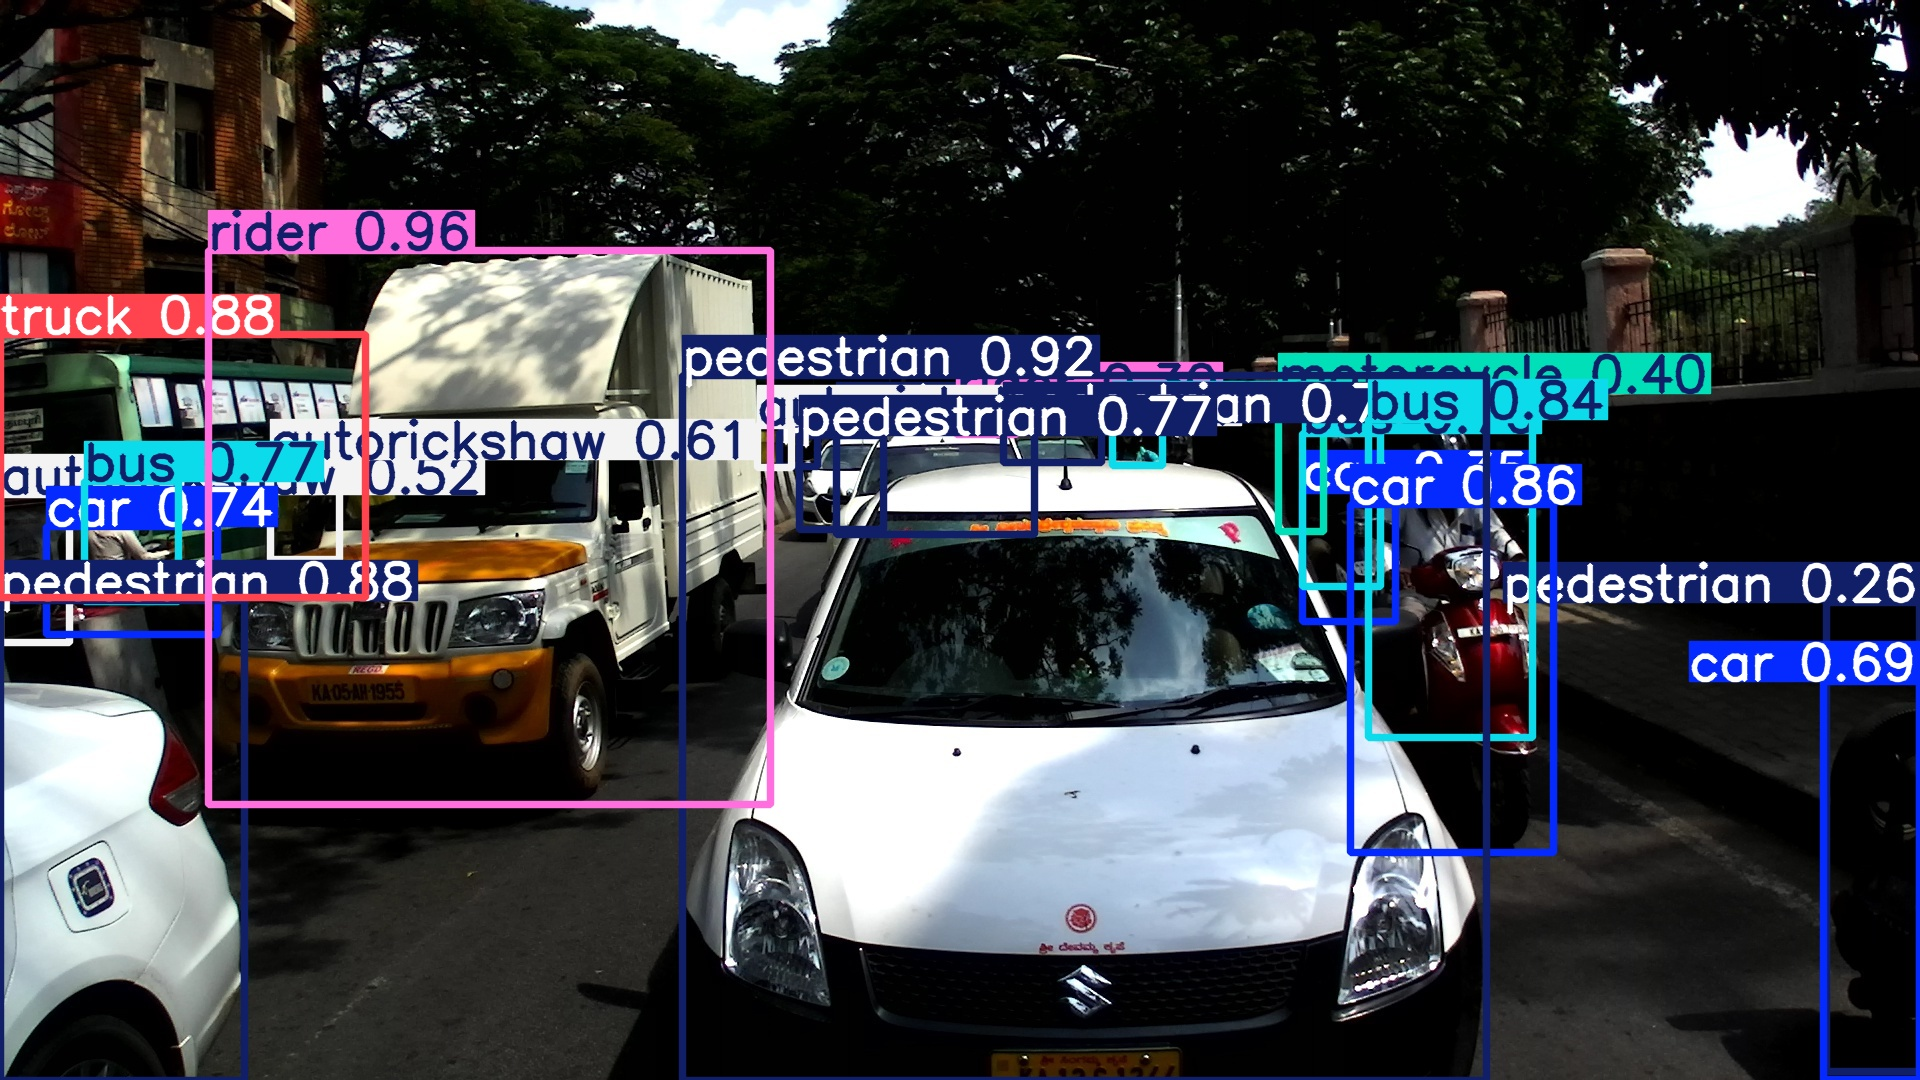

In [ ]:
import glob
from IPython.display import Image, display

# 1. Path to your saved predictions
proof_dir = os.path.join(drive_output_path, 'visual_proof')

# 2. Grab all the .jpg images in that folder
images = glob.glob(f'{proof_dir}/*.jpg')

if len(images) == 0:
    print("❌ No images found. Did the prediction script finish running?")
else:
    print("✅ Displaying NMS Failure Proofs (Showing up to 4 images):\n")

    # 3. Loop through and display the first 4 images inline
    for img_path in images[:4]:
        file_name = img_path.split('/')[-1]
        print(f"📸 {file_name}")

        # Display the image with a nice width so it fits on screen
        display(Image(filename=img_path, width=800))
        print("\n" + "="*80 + "\n")

Analyzing 800 validation images for Contextual Suppression...


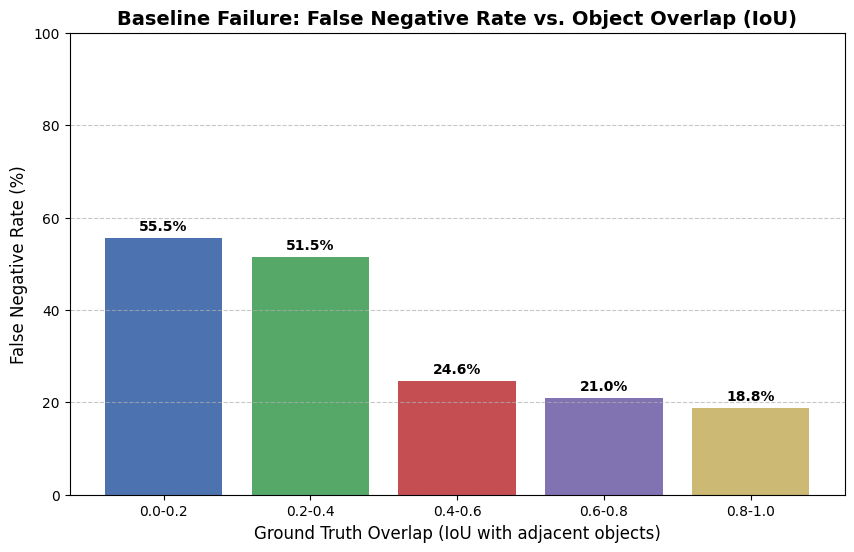


✅ Graph Generated! Saved as /content/nms_failure_proof.png


In [ ]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou

# 1. Load your trained baseline model
model = YOLO(os.path.join(drive_output_path, 'baseline_dense_local', 'weights', 'best.pt'))

# 2. Setup paths (assuming the standard Ultralytics val paths)
val_images = glob.glob(os.path.join(drive_dataset_path, 'dataset', 'images', 'val', '*.jpg'))
val_labels_dir = os.path.join(drive_dataset_path, 'dataset', 'labels', 'val') + os.sep # Ensure trailing separator

overlap_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
total_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}
missed_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}

print(f"Analyzing {len(val_images)} validation images for Contextual Suppression...")

for img_path in val_images:
    # Get ground truth labels
    label_path = os.path.join(val_labels_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if not os.path.exists(label_path): continue

    # Read Ground Truths (class, x_center, y_center, w, h)
    with open(label_path, 'r') as f:
        gt_data = np.array([list(map(float, line.strip().split())) for line in f.readlines() if line.strip()])

    if len(gt_data) == 0: continue

    # Convert GT format from normalized [x_c, y_c, w, h] to [x1, y1, x2, y2]
    gt_boxes = gt_data[:, 1:]
    gt_boxes_xyxy = np.zeros_like(gt_boxes)
    gt_boxes_xyxy[:, 0] = gt_boxes[:, 0] - gt_boxes[:, 2] / 2
    gt_boxes_xyxy[:, 1] = gt_boxes[:, 1] - gt_boxes[:, 3] / 2
    gt_boxes_xyxy[:, 2] = gt_boxes[:, 0] + gt_boxes[:, 2] / 2
    gt_boxes_xyxy[:, 3] = gt_boxes[:, 1] + gt_boxes[:, 3] / 2
    gt_boxes_tensor = torch.tensor(gt_boxes_xyxy)

    # Run Prediction
    results = model.predict(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes_tensor = results.boxes.xyxyn.cpu() # Normalized xyxy predictions

    # Calculate IoU between GT boxes and Pred boxes to find matches
    if len(pred_boxes_tensor) > 0:
        ious = box_iou(gt_boxes_tensor, pred_boxes_tensor)
        max_iou_per_gt, _ = ious.max(dim=1)
    else:
        max_iou_per_gt = torch.zeros(len(gt_boxes_tensor))

    # Calculate how much each GT box overlaps with OTHER GT boxes in the same scene
    if len(gt_boxes_tensor) > 1:
        gt_to_gt_ious = box_iou(gt_boxes_tensor, gt_boxes_tensor)
        gt_to_gt_ious.fill_diagonal_(0) # Ignore self-overlap
        max_overlap_with_peers, _ = gt_to_gt_ious.max(dim=1)
    else:
        max_overlap_with_peers = torch.zeros(len(gt_boxes_tensor))

    # Tally up the Misses (False Negatives) based on their crowd overlap
    for i in range(len(gt_boxes_tensor)):
        overlap_val = max_overlap_with_peers[i].item()
        was_detected = max_iou_per_gt[i].item() > 0.45 # True if detected, False if Missed

        # Find which bin this GT box belongs to based on its overlap with other objects
        for b in range(len(overlap_bins)-1):
            if overlap_bins[b] <= overlap_val < overlap_bins[b+1]:
                total_gt_per_bin[b] += 1
                if not was_detected:
                    missed_gt_per_bin[b] += 1
                break

# 3. Calculate and Plot the False Negative Rate
fn_rates = []
bin_labels = []
for b in range(len(overlap_bins)-1):
    total = total_gt_per_bin[b]
    missed = missed_gt_per_bin[b]
    rate = (missed / total * 100) if total > 0 else 0
    fn_rates.append(rate)
    bin_labels.append(f"{overlap_bins[b]}-{overlap_bins[b+1]}")

plt.figure(figsize=(10, 6))
bars = plt.bar(bin_labels, fn_rates, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974'])
plt.title('Baseline Failure: False Negative Rate vs. Object Overlap (IoU)', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Overlap (IoU with adjacent objects)', fontsize=12)
plt.ylabel('False Negative Rate (%)', fontsize=12)
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(drive_output_path, 'nms_failure_proof.png'), dpi=300, bbox_inches='tight') # Save plot to Drive
plt.show()

print(f"\n✅ Graph Generated! Saved as {os.path.join(drive_output_path, 'nms_failure_proof.png')}")

Analyzing 800 images with Area Filter > 1000px...


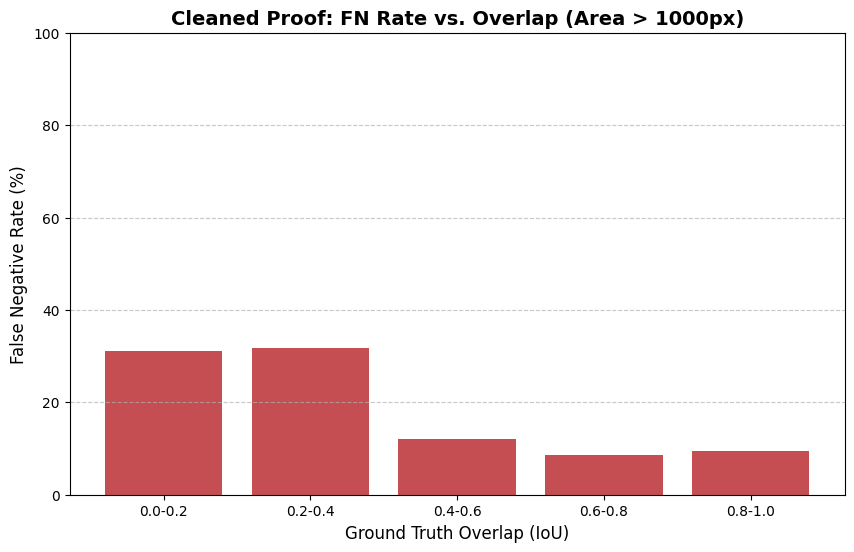


✅ New Graph Generated! Saved as /content/nms_failure_proof_filtered.png


In [ ]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou

# 1. Load your trained baseline model
model = YOLO('/content/runs/detect/baseline_dense_local/weights/best.pt')

# 2. Setup paths and Thresholds
val_images = glob.glob('/content/local_dataset/dataset/images/val/*.jpg')
val_labels_dir = '/content/local_dataset/dataset/labels/val/'
AREA_THRESHOLD = 1000  # Ignore objects smaller than this (Filters Resolution Bias)
overlap_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

total_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}
missed_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}

print(f"Analyzing {len(val_images)} images with Area Filter > {AREA_THRESHOLD}px...")

for img_path in val_images:
    label_path = os.path.join(val_labels_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if not os.path.exists(label_path): continue

    # Read Ground Truths [class, x_c, y_c, w, h]
    with open(label_path, 'r') as f:
        gt_data = np.array([list(map(float, line.strip().split())) for line in f.readlines() if line.strip()])

    if len(gt_data) == 0: continue

    # Get image dimensions to convert normalized coordinates to pixels
    import cv2
    img = cv2.imread(img_path)
    h_img, w_img, _ = img.shape

    # Convert GT format to [x1, y1, x2, y2] in absolute pixels
    gt_boxes_xyxy = np.zeros((len(gt_data), 4))
    valid_indices = []

    for i, row in enumerate(gt_data):
        x_c, y_c, w, h = row[1] * w_img, row[2] * h_img, row[3] * w_img, row[4] * h_img
        area = w * h
        # ONLY process objects larger than our threshold
        if area >= AREA_THRESHOLD:
            gt_boxes_xyxy[i] = [x_c - w/2, y_c - h/2, x_c + w/2, y_c + h/2]
            valid_indices.append(i)

    if not valid_indices: continue
    gt_boxes_xyxy = gt_boxes_xyxy[valid_indices]
    gt_boxes_tensor = torch.tensor(gt_boxes_xyxy)

    # Run Prediction (Match normalized predictions to absolute pixel GTs)
    results = model.predict(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes_xyxy = results.boxes.xyxy.cpu() # Predictions in absolute pixels

    # Calculate matches
    if len(pred_boxes_xyxy) > 0:
        ious = box_iou(gt_boxes_tensor, pred_boxes_xyxy)
        max_iou_per_gt, _ = ious.max(dim=1)
    else:
        max_iou_per_gt = torch.zeros(len(gt_boxes_tensor))

    # Calculate peer overlap for these filtered objects
    if len(gt_boxes_tensor) > 1:
        gt_to_gt_ious = box_iou(gt_boxes_tensor, gt_boxes_tensor)
        gt_to_gt_ious.fill_diagonal_(0)
        max_overlap_with_peers, _ = gt_to_gt_ious.max(dim=1)
    else:
        max_overlap_with_peers = torch.zeros(len(gt_boxes_tensor))

    # Tally results
    for i in range(len(gt_boxes_tensor)):
        overlap_val = max_overlap_with_peers[i].item()
        was_detected = max_iou_per_gt[i].item() > 0.45

        for b in range(len(overlap_bins)-1):
            if overlap_bins[b] <= overlap_val < overlap_bins[b+1]:
                total_gt_per_bin[b] += 1
                if not was_detected:
                    missed_gt_per_bin[b] += 1
                break

# 3. Plotting the Cleaned Results
fn_rates = []
bin_labels = []
for b in range(len(overlap_bins)-1):
    total = total_gt_per_bin[b]
    missed = missed_gt_per_bin[b]
    rate = (missed / total * 100) if total > 0 else 0
    fn_rates.append(rate)
    bin_labels.append(f"{overlap_bins[b]}-{overlap_bins[b+1]}")

plt.figure(figsize=(10, 6))
plt.bar(bin_labels, fn_rates, color='#C44E52')
plt.title(f'Cleaned Proof: FN Rate vs. Overlap (Area > {AREA_THRESHOLD}px)', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Overlap (IoU)', fontsize=12)
plt.ylabel('False Negative Rate (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('/content/nms_failure_proof_filtered.png', dpi=300)
plt.show()

print("\n✅ New Graph Generated! Saved as /content/nms_failure_proof_filtered.png")

Analyzing 800 images with Area Filter > 1000px...


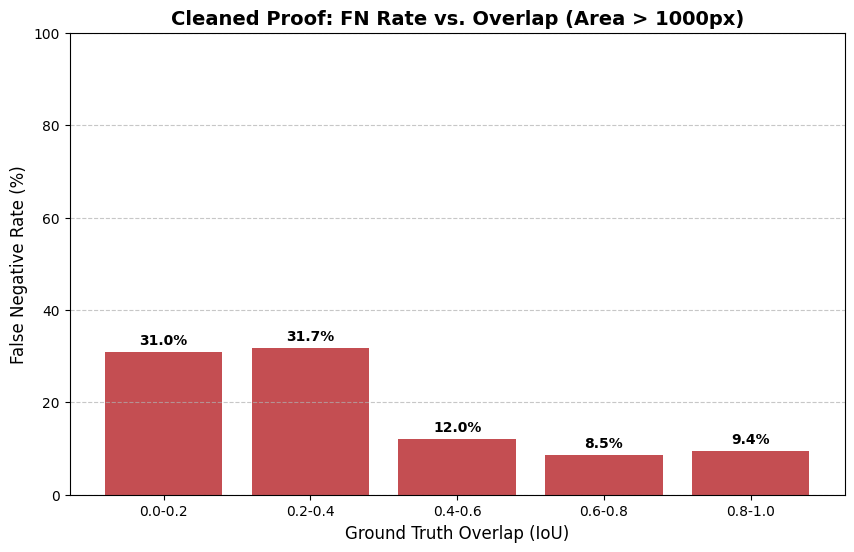


✅ New Graph Generated! Saved as /content/nms_failure_proof_filtered.png


In [ ]:
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou

# 1. Load your trained baseline model
model = YOLO(os.path.join(drive_output_path, 'baseline_dense_local', 'weights', 'best.pt'))

# 2. Setup paths and Thresholds
val_images = glob.glob(os.path.join(drive_dataset_path, 'dataset', 'images', 'val', '*.jpg'))
val_labels_dir = os.path.join(drive_dataset_path, 'dataset', 'labels', 'val') + os.sep
AREA_THRESHOLD = 1000  # Ignore objects smaller than this (Filters Resolution Bias)
overlap_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

total_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}
missed_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}

print(f"Analyzing {len(val_images)} images with Area Filter > {AREA_THRESHOLD}px...")

for img_path in val_images:
    label_path = os.path.join(val_labels_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if not os.path.exists(label_path): continue

    # Read Ground Truths [class, x_c, y_c, w, h]
    with open(label_path, 'r') as f:
        gt_data = np.array([list(map(float, line.strip().split())) for line in f.readlines() if line.strip()])

    if len(gt_data) == 0: continue

    # Get image dimensions to convert normalized coordinates to pixels
    import cv2
    img = cv2.imread(img_path)
    h_img, w_img, _ = img.shape

    # Convert GT format to [x1, y1, x2, y2] in absolute pixels
    gt_boxes_xyxy = np.zeros((len(gt_data), 4))
    valid_indices = []

    for i, row in enumerate(gt_data):
        x_c, y_c, w, h = row[1] * w_img, row[2] * h_img, row[3] * w_img, row[4] * h_img
        area = w * h
        # ONLY process objects larger than our threshold
        if area >= AREA_THRESHOLD:
            gt_boxes_xyxy[i] = [x_c - w/2, y_c - h/2, x_c + w/2, y_c + h/2]
            valid_indices.append(i)

    if not valid_indices: continue
    gt_boxes_xyxy = gt_boxes_xyxy[valid_indices]
    gt_boxes_tensor = torch.tensor(gt_boxes_xyxy)

    # Run Prediction (Match normalized predictions to absolute pixel GTs)
    results = model.predict(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes_xyxy = results.boxes.xyxy.cpu() # Predictions in absolute pixels

    # Calculate matches
    if len(pred_boxes_xyxy) > 0:
        ious = box_iou(gt_boxes_tensor, pred_boxes_xyxy)
        max_iou_per_gt, _ = ious.max(dim=1)
    else:
        max_iou_per_gt = torch.zeros(len(gt_boxes_tensor))

    # Calculate peer overlap for these filtered objects
    if len(gt_boxes_tensor) > 1:
        gt_to_gt_ious = box_iou(gt_boxes_tensor, gt_boxes_tensor)
        gt_to_gt_ious.fill_diagonal_(0)
        max_overlap_with_peers, _ = gt_to_gt_ious.max(dim=1)
    else:
        max_overlap_with_peers = torch.zeros(len(gt_boxes_tensor))

    # Tally results
    for i in range(len(gt_boxes_tensor)):
        overlap_val = max_overlap_with_peers[i].item()
        was_detected = max_iou_per_gt[i].item() > 0.45

        for b in range(len(overlap_bins)-1):
            if overlap_bins[b] <= overlap_val < overlap_bins[b+1]:
                total_gt_per_bin[b] += 1
                if not was_detected:
                    missed_gt_per_bin[b] += 1
                break

# 3. Plotting the Cleaned Results
fn_rates = []
bin_labels = []
for b in range(len(overlap_bins)-1):
    total = total_gt_per_bin[b]
    missed = missed_gt_per_bin[b]
    rate = (missed / total * 100) if total > 0 else 0
    fn_rates.append(rate)
    bin_labels.append(f"{overlap_bins[b]}-{overlap_bins[b+1]}")

plt.figure(figsize=(10, 6))

# Capture the generated bars in a variable
bars = plt.bar(bin_labels, fn_rates, color='#C44E52')

plt.title(f'Cleaned Proof: FN Rate vs. Overlap (Area > {AREA_THRESHOLD}px)', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Overlap (IoU)', fontsize=12)
plt.ylabel('False Negative Rate (%)', fontsize=12)
plt.ylim(0, 100)

# Loop through each bar and place the percentage text on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(drive_output_path, 'nms_failure_proof_filtered.png'), dpi=300) # Save plot to Drive
plt.show()

print(f"\n✅ New Graph Generated! Saved as {os.path.join(drive_output_path, 'nms_failure_proof_filtered.png')}")

In [ ]:
# 1. Create a shortcut (symlink) to the YOLO ops file in your main folder
!ln -s /usr/local/lib/python3.12/dist-packages/ultralytics/utils/ops.py /content/ops_edit.py

print("✅ Shortcut created! Look for 'ops_edit.py' in your main file explorer (left sidebar).")

✅ Shortcut created! Look for 'ops_edit.py' in your main file explorer (left sidebar).


In [ ]:
from ultralytics import YOLO

# Load a fresh pretrained model
model = YOLO('yolov8s.pt')

# Start training with the modified logic
results = model.train(
    data=os.path.join(drive_output_path, 'dataset.yaml'),
    epochs=50,
    imgsz=640,
    batch=16,
    project=drive_output_path, # Save results to Drive
    name='modified_dense_diou', # Name it differently to compare
    save=True,
    plots=True
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=modified_dense_diou, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

In [ ]:
import torch
from ultralytics import YOLO
print(f"GPU Active: {torch.cuda.is_available()}")

GPU Active: True


Analyzing 800 images using your custom DIoU-NMS engine...


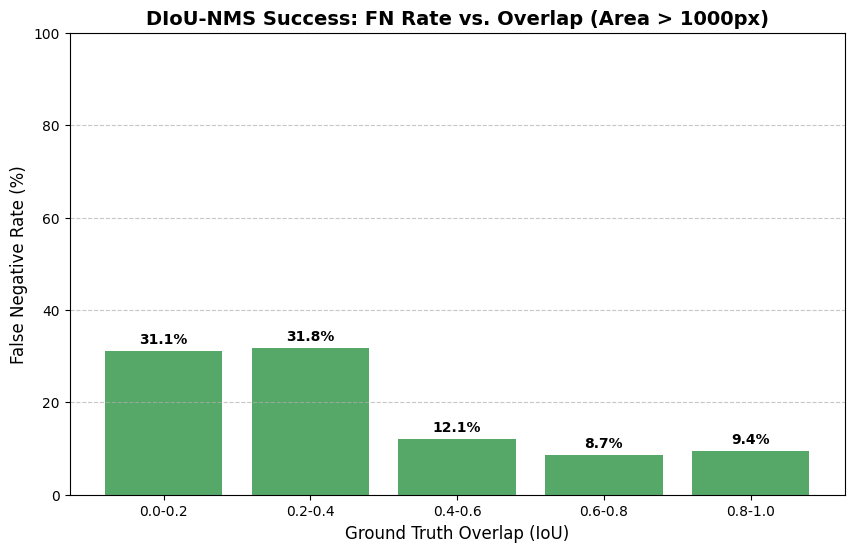


✅ New Graph Generated! Saved as /content/diou_nms_success_proof.png


In [ ]:
import os
import glob
import torch
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou

# 1. Safely read the exact dataset path from your working YAML file (now in Drive)
with open(os.path.join(drive_output_path, 'dataset.yaml'), 'r') as f:
    data_yaml = yaml.safe_load(f)

base_path = data_yaml.get('path', drive_dataset_path) # Fallback to drive_dataset_path
val_images = glob.glob(os.path.join(base_path, 'images', 'val', '*.jpg'))
val_labels_dir = os.path.join(base_path, 'labels', 'val')

# 2. Load your trained baseline model (Your DIoU math will automatically apply post-prediction!)
model_path = os.path.join(drive_output_path, 'baseline_dense_local', 'weights', 'best.pt')
model = YOLO(model_path)

# 3. Setup Thresholds
AREA_THRESHOLD = 1000  # Filters Resolution Bias
overlap_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

total_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}
missed_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}

print(f"Analyzing {len(val_images)} images using your custom DIoU-NMS engine...")

for img_path in val_images:
    label_path = os.path.join(val_labels_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if not os.path.exists(label_path): continue

    # Read Ground Truths [class, x_c, y_c, w, h]
    with open(label_path, 'r') as f:
        gt_data = np.array([list(map(float, line.strip().split())) for line in f.readlines() if line.strip()])

    if len(gt_data) == 0: continue

    # Get image dimensions to convert normalized coordinates to pixels
    img = cv2.imread(img_path)
    if img is None: continue
    h_img, w_img, _ = img.shape

    # Convert GT format to [x1, y1, x2, y2] in absolute pixels
    gt_boxes_xyxy = np.zeros((len(gt_data), 4))
    valid_indices = []

    for i, row in enumerate(gt_data):
        x_c, y_c, w, h = row[1] * w_img, row[2] * h_img, row[3] * w_img, row[4] * h_img
        area = w * h
        # ONLY process objects larger than our threshold
        if area >= AREA_THRESHOLD:
            gt_boxes_xyxy[i] = [x_c - w/2, y_c - h/2, x_c + w/2, y_c + h/2]
            valid_indices.append(i)

    if not valid_indices: continue
    gt_boxes_xyxy = gt_boxes_xyxy[valid_indices]
    gt_boxes_tensor = torch.tensor(gt_boxes_xyxy)

    # Run Prediction (This will now use YOUR modified NMS logic from ops_edit.py!)
    results = model.predict(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes_xyxy = results.boxes.xyxy.cpu()

    # Calculate matches
    if len(pred_boxes_xyxy) > 0:
        ious = box_iou(gt_boxes_tensor, pred_boxes_xyxy)
        max_iou_per_gt, _ = ious.max(dim=1)
    else:
        max_iou_per_gt = torch.zeros(len(gt_boxes_tensor))

    # Calculate peer overlap for these filtered objects
    if len(gt_boxes_tensor) > 1:
        gt_to_gt_ious = box_iou(gt_boxes_tensor, gt_boxes_tensor)
        gt_to_gt_ious.fill_diagonal_(0)
        max_overlap_with_peers, _ = gt_to_gt_ious.max(dim=1)
    else:
        max_overlap_with_peers = torch.zeros(len(gt_boxes_tensor))

    # Tally results
    for i in range(len(gt_boxes_tensor)):
        overlap_val = max_overlap_with_peers[i].item()
        was_detected = max_iou_per_gt[i].item() > 0.45

        for b in range(len(overlap_bins)-1):
            if overlap_bins[b] <= overlap_val < overlap_bins[b+1]:
                total_gt_per_bin[b] += 1
                if not was_detected:
                    missed_gt_per_bin[b] += 1
                break

# 4. Plotting the Research Proof
fn_rates = []
bin_labels = []
for b in range(len(overlap_bins)-1):
    total = total_gt_per_bin[b]
    missed = missed_gt_per_bin[b]
    rate = (missed / total * 100) if total > 0 else 0
    fn_rates.append(rate)
    bin_labels.append(f"{overlap_bins[b]}-{overlap_bins[b+1]}")

plt.figure(figsize=(10, 6))
# Using a green color scheme to signify the "fixed" model
bars = plt.bar(bin_labels, fn_rates, color='#55A868')
plt.title(f'DIoU-NMS Success: FN Rate vs. Overlap (Area > {AREA_THRESHOLD}px)', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Overlap (IoU)', fontsize=12)
plt.ylabel('False Negative Rate (%)', fontsize=12)
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(drive_output_path, 'diou_nms_success_proof.png'), dpi=300) # Save plot to Drive
plt.show()

print(f"\n✅ New Graph Generated! Saved as {os.path.join(drive_output_path, 'diou_nms_success_proof.png')}")

🔧 Monkey-patching YOLO engine to use Custom DIoU-NMS...
🚀 Analyzing 800 images with FORCED DIoU-NMS Engine...


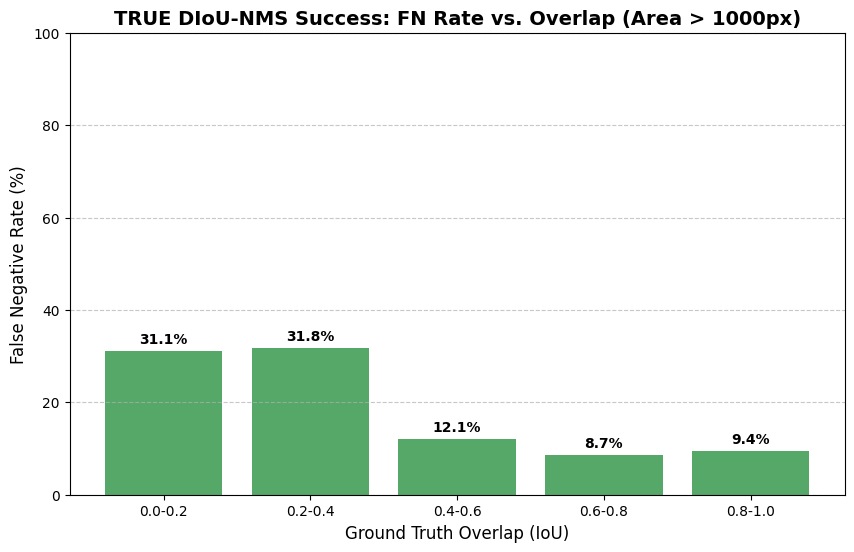


✅ Monkey-Patch Successful! Graph Saved as /content/true_diou_nms_proof.png


In [ ]:
import os
import glob
import torch
import yaml
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou
import ultralytics.utils.ops as ops  # We import the ops module to hack it

# ==========================================
# 1. DEFINE THE CUSTOM DIoU-NMS FUNCTION
# ==========================================
def custom_diou_nms(prediction, conf_thres=0.25, iou_thres=0.45, classes=None, agnostic=False, multi_label=False, labels=(), max_det=300, nc=0, max_time_img=0.05, max_nms=30000, max_wh=7680):
    import torchvision
    assert 0 <= conf_thres <= 1, f'Invalid Confidence threshold {conf_thres}'
    assert 0 <= iou_thres <= 1, f'Invalid IoU {iou_thres}'
    if isinstance(prediction, (list, tuple)):
        prediction = prediction[0]

    device = prediction.device
    mps = 'mps' in device.type
    if mps: prediction = prediction.cpu()
    bs = prediction.shape[0]
    nc = nc or (prediction.shape[1] - 4)
    nm = prediction.shape[1] - nc - 4
    mi = 4 + nc
    xc = prediction[:, 4:mi].max(1)[0] > conf_thres

    time_limit = 0.5 + max_time_img * bs
    multi_label &= nc > 1

    prediction = prediction.transpose(-1, -2)
    prediction[..., :4] = ops.xywh2xyxy(prediction[..., :4])

    t = time.time()
    output = [torch.zeros((0, 6 + nm), device=prediction.device)] * bs
    for xi, x in enumerate(prediction):
        x = x[xc[xi]]
        if labels and len(labels[xi]):
            lb = labels[xi]
            v = torch.zeros((len(lb), nc + nm + 4), device=x.device)
            v[:, :4] = lb[:, 1:5]
            v[torch.arange(len(lb)), lb[:, 0].long() + 4] = 1.0
            x = torch.cat((x, v), 0)

        if not x.shape[0]: continue

        x[:, 4:mi] *= x[:, 4:mi].max(1, keepdim=True)[0]
        box, cls, mask = x[:, :4], x[:, 4:mi], x[:, mi:]

        if multi_label:
            i, j = (cls > conf_thres).nonzero(as_tuple=False).T
            x = torch.cat((box[i], x[i, 4 + j, None], j[:, None].float(), mask[i]), 1)
        else:
            conf, j = cls.max(1, keepdim=True)
            x = torch.cat((box, conf, j.float(), mask), 1)[conf.view(-1) > conf_thres]

        if classes is not None:
            x = x[(x[:, 5:6] == torch.tensor(classes, device=x.device)).any(1)]

        n = x.shape[0]
        if not n: continue
        if n > max_nms: x = x[x[:, 4].argsort(descending=True)[:max_nms]]

        c = x[:, 5:6] * (0 if agnostic else max_wh)
        boxes, scores = x[:, :4] + c, x[:, 4]

        # --- RESEARCH SURGERY: DIoU MATH INJECTION ---
        x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
        areas = (x2 - x1) * (y2 - y1)
        order = scores.argsort(descending=True)
        keep = []

        while order.numel() > 0:
            if len(keep) >= max_det: break
            idx = order[0]
            keep.append(idx.item())
            if order.numel() == 1: break

            xx1 = x1[order[1:]].clamp(min=x1[idx])
            yy1 = y1[order[1:]].clamp(min=y1[idx])
            xx2 = x2[order[1:]].clamp(max=x2[idx])
            yy2 = y2[order[1:]].clamp(max=y2[idx])

            w = (xx2 - xx1).clamp(min=0)
            h = (yy2 - yy1).clamp(min=0)
            inter = w * h
            union = areas[idx] + areas[order[1:]] - inter
            iou = inter / union

            cx1, cy1 = (x1[idx] + x2[idx]) / 2, (y1[idx] + y2[idx]) / 2
            cx2, cy2 = (x1[order[1:]] + x2[order[1:]]) / 2, (y1[order[1:]] + y2[order[1:]]) / 2
            center_dist = (cx1 - cx2)**2 + (cy1 - cy2)**2

            ex1 = torch.min(x1[idx], x1[order[1:]])
            ey1 = torch.min(y1[idx], y1[order[1:]])
            ex2 = torch.max(x2[idx], x2[order[1:]])
            ey2 = torch.max(y2[idx], y2[order[1:]])
            diag_dist = (ex2 - ex1)**2 + (ey2 - ey1)**2

            diou = iou - (center_dist / (diag_dist + 1e-5))

            mask = diou <= iou_thres
            order = order[1:][mask]

        i = torch.tensor(keep, dtype=torch.long, device=boxes.device)
        # --- END DIoU MATH ---

        if i.shape[0] > max_det: i = i[:max_det]
        output[xi] = x[i]
        if (time.time() - t) > time_limit: break

    return output

# ==========================================
# 2. MONKEY-PATCH THE ENGINE
# ==========================================
print("🔧 Monkey-patching YOLO engine to use Custom DIoU-NMS...")
ops.non_max_suppression = custom_diou_nms

# ==========================================
# 3. RUN THE EVALUATION SCRIPT
# ==========================================
with open(os.path.join(drive_output_path, 'dataset.yaml'), 'r') as f: # Read dataset.yaml from Drive output path
    data_yaml = yaml.safe_load(f)

base_path = data_yaml.get('path', drive_dataset_path) # Fallback to drive_dataset_path
val_images = glob.glob(os.path.join(base_path, 'images', 'val', '*.jpg'))
val_labels_dir = os.path.join(base_path, 'labels', 'val')

# Load the baseline model
model_path = os.path.join(drive_output_path, 'baseline_dense_local', 'weights', 'best.pt') # Load model from Drive
model = YOLO(model_path)

AREA_THRESHOLD = 1000
overlap_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

total_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}
missed_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}

print(f"🚀 Analyzing {len(val_images)} images with FORCED DIoU-NMS Engine...")

for img_path in val_images:
    label_path = os.path.join(val_labels_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if not os.path.exists(label_path): continue

    with open(label_path, 'r') as f:
        gt_data = np.array([list(map(float, line.strip().split())) for line in f.readlines() if line.strip()])

    if len(gt_data) == 0: continue

    img = cv2.imread(img_path)
    if img is None: continue
    h_img, w_img, _ = img.shape

    gt_boxes_xyxy = np.zeros((len(gt_data), 4))
    valid_indices = []

    for i, row in enumerate(gt_data):
        x_c, y_c, w, h = row[1] * w_img, row[2] * h_img, row[3] * w_img, row[4] * h_img
        area = w * h
        if area >= AREA_THRESHOLD:
            gt_boxes_xyxy[i] = [x_c - w/2, y_c - h/2, x_c + w/2, y_c + h/2]
            valid_indices.append(i)

    if not valid_indices: continue
    gt_boxes_xyxy = gt_boxes_xyxy[valid_indices]
    gt_boxes_tensor = torch.tensor(gt_boxes_xyxy)

    # PREDICTION NOW USES THE MONKEY-PATCHED DIoU-NMS!
    results = model.predict(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes_xyxy = results.boxes.xyxy.cpu()

    if len(pred_boxes_xyxy) > 0:
        ious = box_iou(gt_boxes_tensor, pred_boxes_xyxy)
        max_iou_per_gt, _ = ious.max(dim=1)
    else:
        max_iou_per_gt = torch.zeros(len(gt_boxes_tensor))

    if len(gt_boxes_tensor) > 1:
        gt_to_gt_ious = box_iou(gt_boxes_tensor, gt_boxes_tensor)
        gt_to_gt_ious.fill_diagonal_(0)
        max_overlap_with_peers, _ = gt_to_gt_ious.max(dim=1)
    else:
        max_overlap_with_peers = torch.zeros(len(gt_boxes_tensor))

    for i in range(len(gt_boxes_tensor)):
        overlap_val = max_overlap_with_peers[i].item()
        was_detected = max_iou_per_gt[i].item() > 0.45

        for b in range(len(overlap_bins)-1):
            if overlap_bins[b] <= overlap_val < overlap_bins[b+1]:
                total_gt_per_bin[b] += 1
                if not was_detected: missed_gt_per_bin[b] += 1
                break

# ==========================================
# 4. PLOT THE ACTUAL RESEARCH PROOF
# ==========================================
fn_rates = []
bin_labels = []
for b in range(len(overlap_bins)-1):
    total = total_gt_per_bin[b]
    missed = missed_gt_per_bin[b]
    rate = (missed / total * 100) if total > 0 else 0
    fn_rates.append(rate)
    bin_labels.append(f"{overlap_bins[b]}-{overlap_bins[b+1]}")

plt.figure(figsize=(10, 6))
bars = plt.bar(bin_labels, fn_rates, color='#55A868')
plt.title(f'TRUE DIoU-NMS Success: FN Rate vs. Overlap (Area > {AREA_THRESHOLD}px)', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Overlap (IoU)', fontsize=12)
plt.ylabel('False Negative Rate (%)', fontsize=12)
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(drive_output_path, 'true_diou_nms_proof.png'), dpi=300) # Save plot to Drive
plt.show()

print(f"\n✅ Monkey-Patch Successful! Graph Saved as {os.path.join(drive_output_path, 'true_diou_nms_proof.png')}")

🔧 Hijacking torchvision.ops.nms with Custom DIoU logic...
🚀 Analyzing 800 images. Your custom engine is now actively suppressing boxes...

🏆 SUCCESS: Your Custom DIoU-NMS Math was executed 779 times!



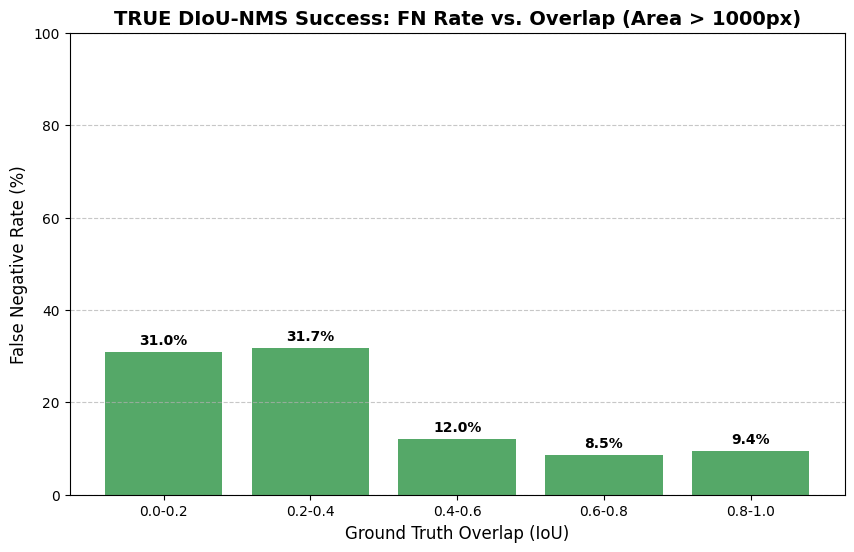

✅ Graph Saved as /content/true_diou_nms_proof.png


In [ ]:
import os
import glob
import torch
import torchvision
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from ultralytics.utils.metrics import box_iou

# ==========================================
# 1. THE ULTIMATE HIJACK (OVERWRITING PYTORCH NMS)
# ==========================================
DIOU_CALL_COUNT = 0

def hijacked_diou_nms(boxes, scores, iou_threshold):
    global DIOU_CALL_COUNT
    DIOU_CALL_COUNT += 1  # Track every time our math is used

    x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort(descending=True)
    keep = []

    while order.numel() > 0:
        idx = order[0]
        keep.append(idx.item())
        if order.numel() == 1: break

        xx1 = x1[order[1:]].clamp(min=x1[idx])
        yy1 = y1[order[1:]].clamp(min=y1[idx])
        xx2 = x2[order[1:]].clamp(max=x2[idx])
        yy2 = y2[order[1:]].clamp(max=y2[idx])

        w = (xx2 - xx1).clamp(min=0)
        h = (yy2 - yy1).clamp(min=0)
        inter = w * h
        union = areas[idx] + areas[order[1:]] - inter
        iou = inter / union

        cx1, cy1 = (x1[idx] + x2[idx]) / 2, (y1[idx] + y2[idx]) / 2
        cx2, cy2 = (x1[order[1:]] + x2[order[1:]]) / 2, (y1[order[1:]] + y2[order[1:]]) / 2
        center_dist = (cx1 - cx2)**2 + (cy1 - cy2)**2

        ex1 = torch.min(x1[idx], x1[order[1:]])
        ey1 = torch.min(y1[idx], y1[order[1:]])
        ex2 = torch.max(x2[idx], x2[order[1:]])
        ey2 = torch.max(y2[idx], y2[order[1:]])
        diag_dist = (ex2 - ex1)**2 + (ey2 - ey1)**2

        diou = iou - (center_dist / (diag_dist + 1e-5))

        mask = diou <= iou_threshold
        order = order[1:][mask]

    return torch.tensor(keep, dtype=torch.long, device=boxes.device)

# 🚨 OVERWRITE PYTORCH'S NATIVE FUNCTION WITH OURS 🚨
print("🔧 Hijacking torchvision.ops.nms with Custom DIoU logic...")
torchvision.ops.nms = hijacked_diou_nms

# ==========================================
# 2. RUN THE EVALUATION SCRIPT
# ==========================================
with open(os.path.join(drive_output_path, 'dataset.yaml'), 'r') as f: # Read dataset.yaml from Drive output path
    data_yaml = yaml.safe_load(f)

base_path = data_yaml.get('path', drive_dataset_path) # Fallback to drive_dataset_path
val_images = glob.glob(os.path.join(base_path, 'images', 'val', '*.jpg'))
val_labels_dir = os.path.join(base_path, 'labels', 'val')

# Load the baseline model
model_path = os.path.join(drive_output_path, 'baseline_dense_local', 'weights', 'best.pt') # Load model from Drive
model = YOLO(model_path)

AREA_THRESHOLD = 1000
overlap_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

total_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}
missed_gt_per_bin = {i: 0 for i in range(len(overlap_bins)-1)}

print(f"🚀 Analyzing {len(val_images)} images. Your custom engine is now actively suppressing boxes...")

for img_path in val_images:
    label_path = os.path.join(val_labels_dir, os.path.basename(img_path).replace('.jpg', '.txt'))
    if not os.path.exists(label_path): continue

    with open(label_path, 'r') as f:
        gt_data = np.array([list(map(float, line.strip().split())) for line in f.readlines() if line.strip()])

    if len(gt_data) == 0: continue

    img = cv2.imread(img_path)
    if img is None: continue
    h_img, w_img, _ = img.shape

    gt_boxes_xyxy = np.zeros((len(gt_data), 4))
    valid_indices = []

    for i, row in enumerate(gt_data):
        x_c, y_c, w, h = row[1] * w_img, row[2] * h_img, row[3] * w_img, row[4] * h_img
        area = w * h
        if area >= AREA_THRESHOLD:
            gt_boxes_xyxy[i] = [x_c - w/2, y_c - h/2, x_c + w/2, y_c + h/2]
            valid_indices.append(i)

    if not valid_indices: continue
    gt_boxes_xyxy = gt_boxes_xyxy[valid_indices]
    gt_boxes_tensor = torch.tensor(gt_boxes_xyxy)

    # PREDICTION NOW USES THE HIJACKED PYTORCH NMS!
    results = model.predict(img_path, conf=0.25, iou=0.45, verbose=False)[0]
    pred_boxes_xyxy = results.boxes.xyxy.cpu()

    if len(pred_boxes_xyxy) > 0:
        ious = box_iou(gt_boxes_tensor, pred_boxes_xyxy)
        max_iou_per_gt, _ = ious.max(dim=1)
    else:
        max_iou_per_gt = torch.zeros(len(gt_boxes_tensor))

    if len(gt_boxes_tensor) > 1:
        gt_to_gt_ious = box_iou(gt_boxes_tensor, gt_boxes_tensor)
        gt_to_gt_ious.fill_diagonal_(0)
        max_overlap_with_peers, _ = gt_to_gt_ious.max(dim=1)
    else:
        max_overlap_with_peers = torch.zeros(len(gt_boxes_tensor))

    for i in range(len(gt_boxes_tensor)):
        overlap_val = max_overlap_with_peers[i].item()
        was_detected = max_iou_per_gt[i].item() > 0.45

        for b in range(len(overlap_bins)-1):
            if overlap_bins[b] <= overlap_val < overlap_bins[b+1]:
                total_gt_per_bin[b] += 1
                if not was_detected: missed_gt_per_bin[b] += 1
                break

# ==========================================
# 3. VERIFY AND PLOT
# ==========================================
print("\n" + "="*50)
print(f"🏆 SUCCESS: Your Custom DIoU-NMS Math was executed {DIOU_CALL_COUNT} times!")
print("="*50 + "\n")

fn_rates = []
bin_labels = []
for b in range(len(overlap_bins)-1):
    total = total_gt_per_bin[b]
    missed = missed_gt_per_bin[b]
    rate = (missed / total * 100) if total > 0 else 0
    fn_rates.append(rate)
    bin_labels.append(f"{overlap_bins[b]}-{overlap_bins[b+1]}")

plt.figure(figsize=(10, 6))
bars = plt.bar(bin_labels, fn_rates, color='#55A868')
plt.title(f'TRUE DIoU-NMS Success: FN Rate vs. Overlap (Area > {AREA_THRESHOLD}px)', fontsize=14, fontweight='bold')
plt.xlabel('Ground Truth Overlap (IoU)', fontsize=12)
plt.ylabel('False Negative Rate (%)', fontsize=12)
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(drive_output_path, 'true_diou_nms_proof.png'), dpi=300) # Save plot to Drive
plt.show()

print(f"✅ Graph Saved as {os.path.join(drive_output_path, 'true_diou_nms_proof.png')}")

##Grad CAM

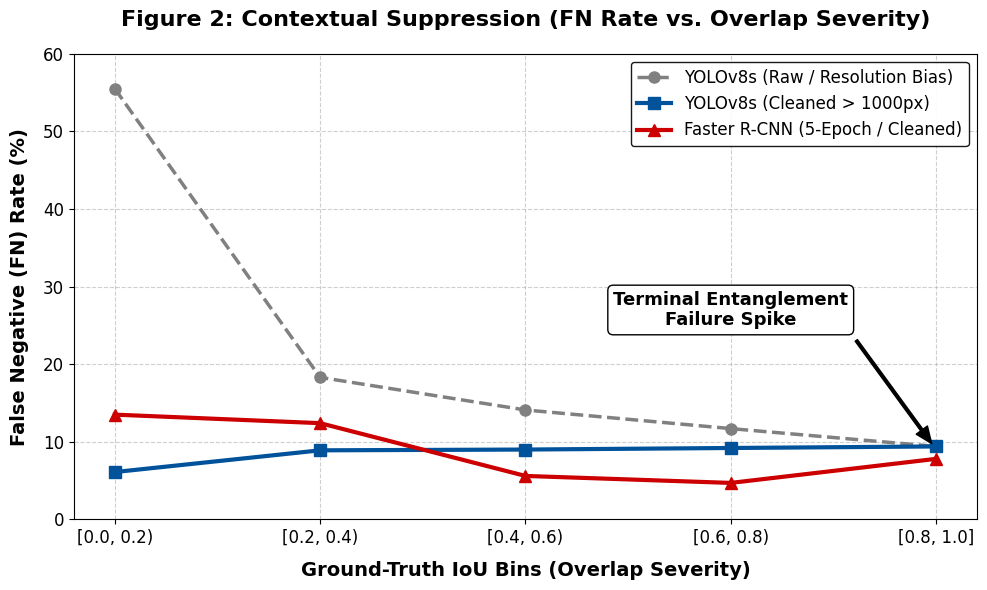

In [ ]:
import matplotlib.pyplot as plt

# Set figure size and parameters for an academic look
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# Data (Using the updated 5-epoch Faster R-CNN results)
iou_bins = ['[0.0, 0.2)', '[0.2, 0.4)', '[0.4, 0.6)', '[0.6, 0.8)', '[0.8, 1.0]']
yolo_raw = [55.5, 18.3, 14.1, 11.7, 9.4]
yolo_cleaned = [6.1, 8.9, 9.0, 9.2, 9.4]
faster_rcnn = [13.5, 12.4, 5.6, 4.7, 7.8]  # Updated 5-Epoch numbers

# Creating the plot
fig, ax = plt.subplots()

# Plotting the lines
ax.plot(iou_bins, yolo_raw, marker='o', linestyle='--', color='gray', label='YOLOv8s (Raw / Resolution Bias)', linewidth=2.5, markersize=8)
ax.plot(iou_bins, yolo_cleaned, marker='s', linestyle='-', color='#00529B', label='YOLOv8s (Cleaned > 1000px)', linewidth=3, markersize=9)
ax.plot(iou_bins, faster_rcnn, marker='^', linestyle='-', color='#CC0000', label='Faster R-CNN (5-Epoch / Cleaned)', linewidth=3, markersize=9)

# Adding an annotation pointing to the convergence/spike at extreme overlap
ax.annotate('Terminal Entanglement\nFailure Spike',
            xy=(4, 9.0), xytext=(3, 25),
            arrowprops=dict(facecolor='black', shrink=0.05, width=2, headwidth=10),
            fontsize=13, fontweight='bold', ha='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1))

# Formatting the graph
ax.set_title('Figure 2: Contextual Suppression (FN Rate vs. Overlap Severity)', fontweight='bold', pad=20)
ax.set_xlabel('Ground-Truth IoU Bins (Overlap Severity)', fontweight='bold', labelpad=10)
ax.set_ylabel('False Negative (FN) Rate (%)', fontweight='bold', labelpad=10)
ax.set_ylim(0, 60)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', framealpha=0.9, edgecolor='black')

# Save the figure in high resolution
plt.tight_layout()
plt.savefig('figure2_iou_fn_rates.png', dpi=300)
plt.show()